In [1]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns;sns.set()
import glob
import os
import re
from joblib import dump

In [2]:
from warnings import filterwarnings
filterwarnings("ignore")

# Loading Image Data

In [3]:
CLASSES = {0:"chris_evans",1:"chris_hemsworth",2:"mark_ruffalo",3:"robert_downey_jr",4:"scarlett_johansson"}
images_paths = glob.glob("images/*.png")

In [4]:
images = []
labels = []

reversed_classes = dict(zip(CLASSES.values(),CLASSES.keys()))

for path in images_paths:
    images.append(cv2.imread(path))
    label = re.search(r"images\\(.*?)\d+\.png",path).group(1)
    labels.append(reversed_classes[label])

# Preprocessing Image Data

In [5]:
min_width = min([image.shape[1] for image in images])
min_height = min([image.shape[0] for image in images])

print("min_width:",min_width)
print("min_height:",min_height)

min_width: 90
min_height: 90


In [6]:
# Resize Images
images = np.array([cv2.resize(image, (90,90), interpolation=cv2.INTER_AREA) for image in images])

In [7]:
# Normalization
images = images / 255

In [8]:
# Flatten
flat_images = images.reshape(60,-1)

In [104]:
# Store the Processed Images and their labels
np.save("artifacts/images.npy", flat_images)
np.save("artifacts/labels.npy", labels)

# Compression

In [9]:
def visualize_faces(estimator_name,recovered_images, start=5, num_imgs=3):
    fig, axs = plt.subplots(num_imgs, 2, figsize=(10, 5*num_imgs))
    
    k = 0
    for i in range(start,start+num_imgs):
        axs[k,0].imshow(images[i])
        axs[k,0].set_title("Original")
        axs[k,0].grid(False)
        axs[k,0].axis(False)
    
        k += 1
    
    k = 0
    for i in range(start,start+num_imgs):
        axs[k,1].imshow(recovered_images[i].reshape(90, 90, 3))
        axs[k,1].set_title(f"Recovered from {estimator_name}")
        axs[k,1].grid(False)
        axs[k,1].axis(False)
    
        k += 1
    plt.show()

In [11]:
def visualization_2d(estimator_name, reduced_images):
    colors = sns.color_palette(n_colors=len(CLASSES))
    for i in np.unique(labels):
        indices = np.where(np.array(labels) == i)[0]
        sns.scatterplot(
            x=reduced_images[indices, 0],
            y=reduced_images[indices, 1],
            color=colors[i],
            label=CLASSES[i]
        )

    plt.title(f"2D Visualization with {estimator_name}")
    plt.legend(title="Class")
    plt.show()

def visualization_3d(estimator_name, reduced_images):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    colors = sns.color_palette(n_colors=len(CLASSES))
    for i in np.unique(labels):
        indices = np.where(np.array(labels) == i)[0]
        ax.scatter(
            reduced_images[indices, 0],
            reduced_images[indices, 1],
            reduced_images[indices, 2],
            c=[colors[i]],
            label=CLASSES[i]
        )
    
    ax.set_title(f"3D Visualization with {estimator_name}")
    ax.legend(title="Class")
    plt.show()

## PCA

In [12]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

In [13]:
pca = PCA(n_components=50,svd_solver='full')
pca.fit(flat_images)

PCA(n_components=50, svd_solver='full')

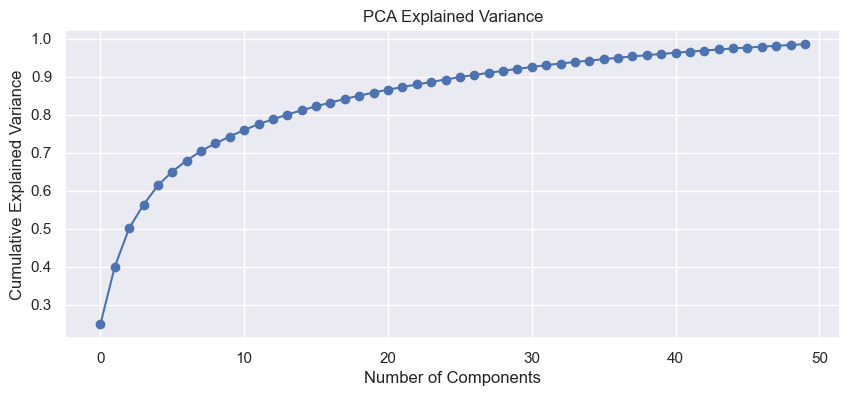

In [14]:
importances = pca.explained_variance_ratio_

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(importances), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

In [15]:
print("With 50 Features only, PCA preserved: ",np.cumsum(importances).max())

With 50 Features only, PCA preserved:  0.9858047581936138


In [16]:
pca_reduced = pca.transform(flat_images)

In [17]:
# Reconstruction
pca_recovered = pca.inverse_transform(pca_reduced)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


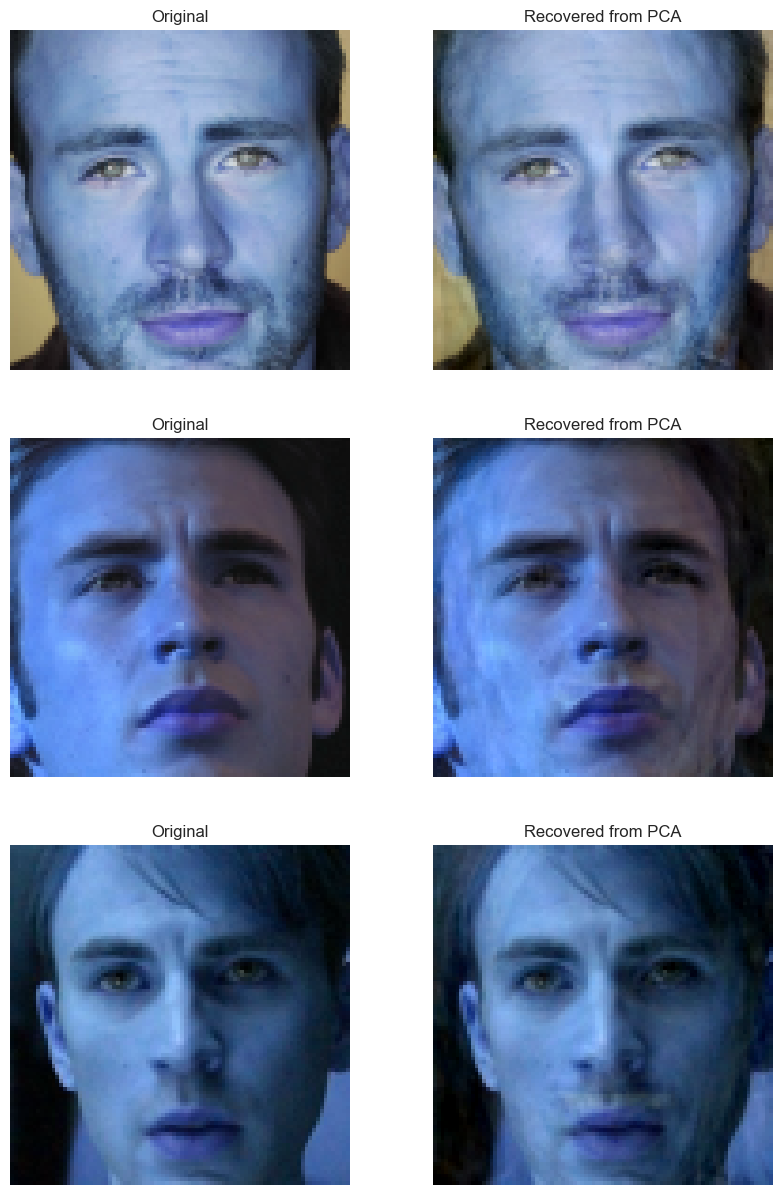

In [18]:
visualize_faces("PCA",pca_recovered)

In [19]:
print("Error between original and recovered images:",mean_squared_error(flat_images,pca_recovered))

Error between original and recovered images: 0.0006232390141663717


In [89]:
# Visualization
pca_2d = PCA(n_components=2,svd_solver='full')
pca_2d_reduced = pca_2d.fit_transform(flat_images)
dump(pca_2d,"estimators/pca_2d.pkl")

pca_3d = PCA(n_components=3,svd_solver='full')
pca_3d_reduced = pca_3d.fit_transform(flat_images)
dump(pca_3d,"estimators/pca_3d.pkl")

['estimators/pca_3d.pkl']

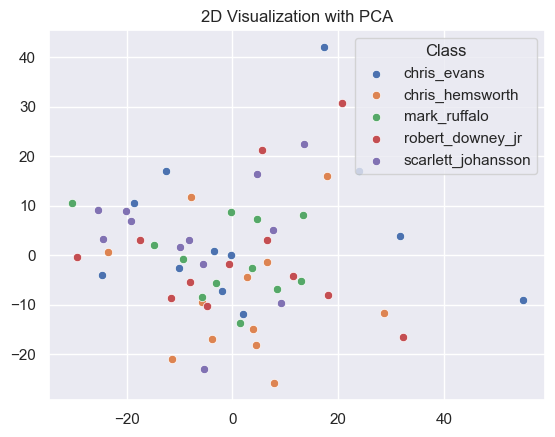

In [21]:
visualization_2d("PCA",pca_2d_reduced)

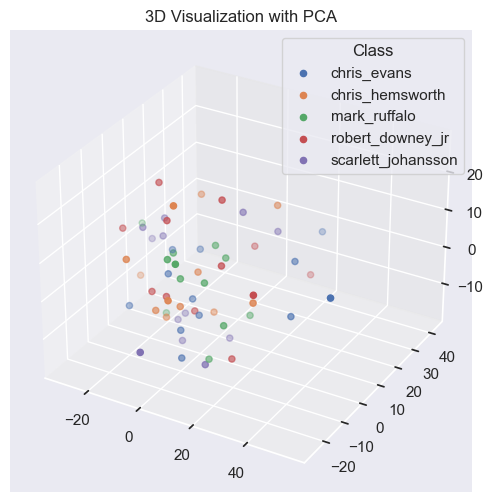

In [22]:
visualization_3d("PCA",pca_3d_reduced)

### Randomized PCA

In [23]:
rand_pca = PCA(n_components=50, svd_solver='randomized', random_state=42)
rand_pca.fit(flat_images)

PCA(n_components=50, random_state=42, svd_solver='randomized')

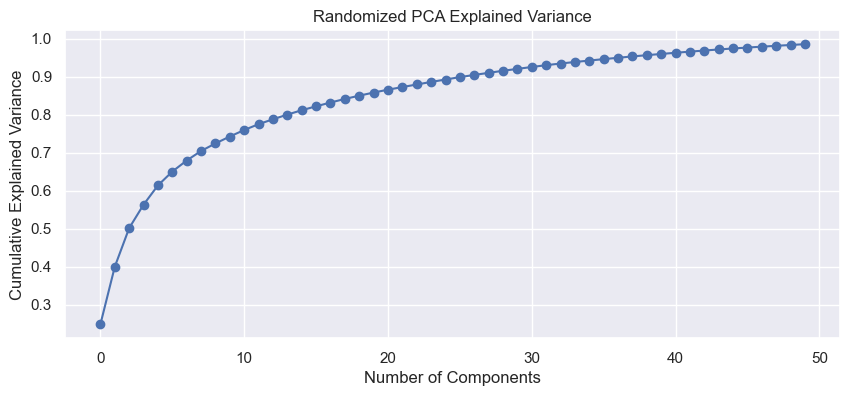

In [24]:
importances = rand_pca.explained_variance_ratio_

plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(importances), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Randomized PCA Explained Variance')
plt.show()

In [25]:
print("With 50 Features only, Randomized PCA preserved: ",np.cumsum(importances).max())

With 50 Features only, Randomized PCA preserved:  0.9858047581936136


In [26]:
rand_pca_reduced = rand_pca.transform(flat_images)

In [27]:
# Reconstruction
rand_pca_recovered = rand_pca.inverse_transform(rand_pca_reduced)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


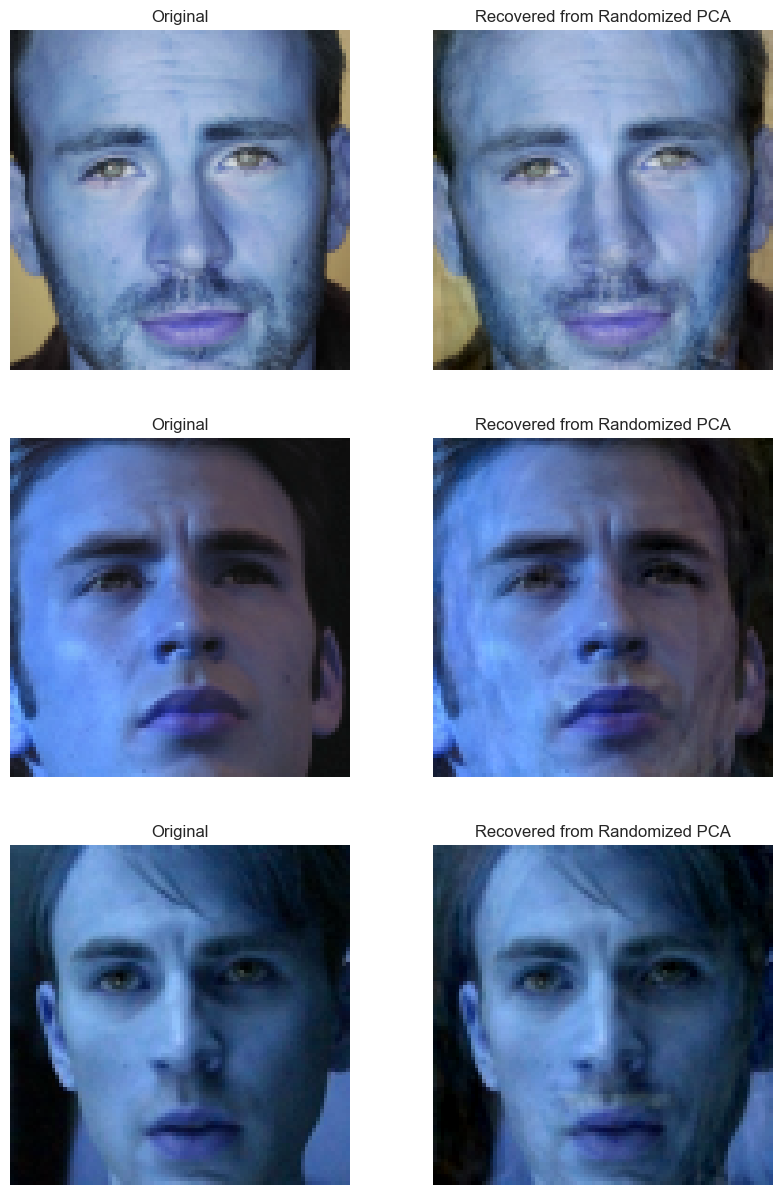

In [28]:
visualize_faces("Randomized PCA",rand_pca_recovered)

So with **Randomized PCA** we got the same results as **PCA** with much less resources and time.

In [29]:
print("Error between original and recovered images:",mean_squared_error(flat_images,rand_pca_recovered))

Error between original and recovered images: 0.0006232390141663716


In [30]:
# Visualization
rand_pca_2d_reduced = PCA(n_components=2, svd_solver='randomized', random_state=42).fit_transform(flat_images)
rand_pca_3d_reduced = PCA(n_components=3, svd_solver='randomized', random_state=42).fit_transform(flat_images)

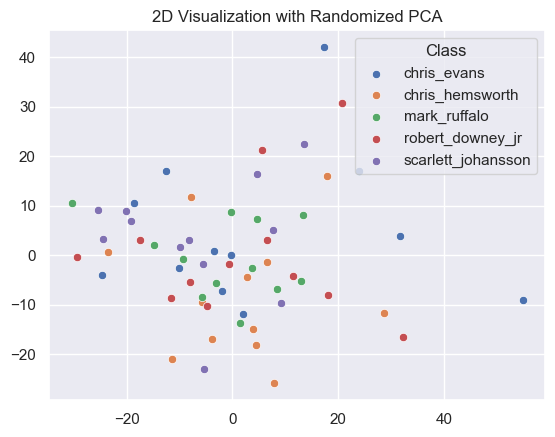

In [31]:
visualization_2d("Randomized PCA",rand_pca_2d_reduced)

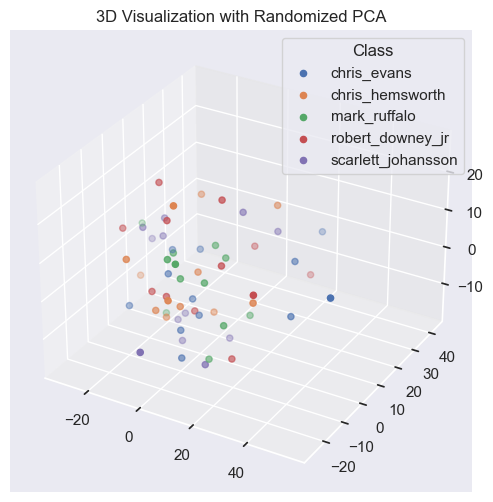

In [32]:
visualization_3d("Randomized PCA",rand_pca_3d_reduced)

### Kernel PCA

In [33]:
from sklearn.decomposition import KernelPCA

In [34]:
kpca = KernelPCA(n_components=50, kernel='rbf', gamma=0.1,fit_inverse_transform=True)
kpca.fit(flat_images)

KernelPCA(fit_inverse_transform=True, gamma=0.1, kernel='rbf', n_components=50)

**KernelPCA** is nonlinear, and it doesn’t compute the variance explained in the same way as regular PCA. So it does not have the .explained_variance_ratio_ attribute.

In [35]:
kpca_reduced = kpca.transform(flat_images)

In [36]:
# Reconstruction
kpca_recovered = kpca.inverse_transform(kpca_reduced)

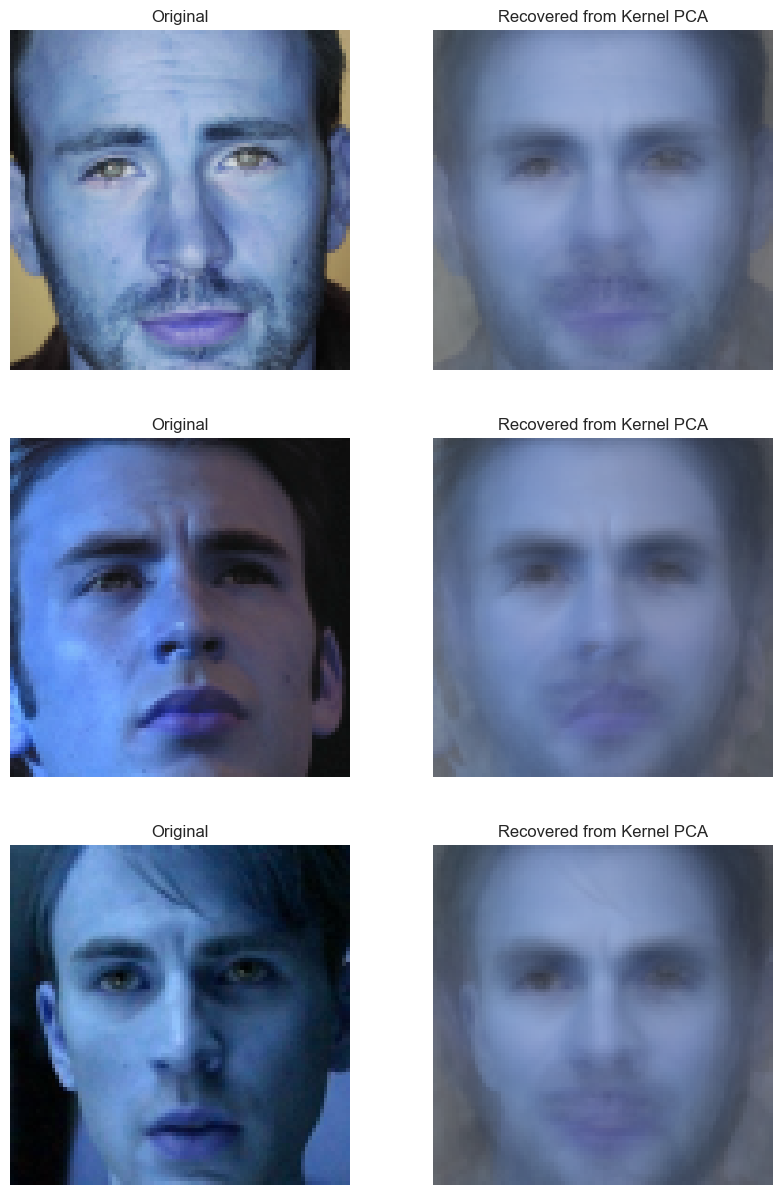

In [37]:
visualize_faces("Kernel PCA",kpca_recovered)

**Kernel PCA** perfomed much worse than linear PCA while its much more powerfull, which means its **overfitting**.

In [38]:
print("Error between original and recovered images:",mean_squared_error(flat_images,kpca_recovered))

Error between original and recovered images: 0.03341017188982809


In [90]:
# Visualization
kpca_2d = KernelPCA(n_components=2, kernel='rbf', gamma=0.1,fit_inverse_transform=True)
kpca_2d_reduced = kpca_2d.fit_transform(flat_images)
dump(kpca_2d,"estimators/kpca_2d.pkl")

kpca_3d = KernelPCA(n_components=3, kernel='rbf', gamma=1e-2, fit_inverse_transform=True)
kpca_3d_reduced = kpca_3d.fit_transform(flat_images)
dump(kpca_3d,"estimators/kpca_3d.pkl")

['estimators/kpca_3d.pkl']

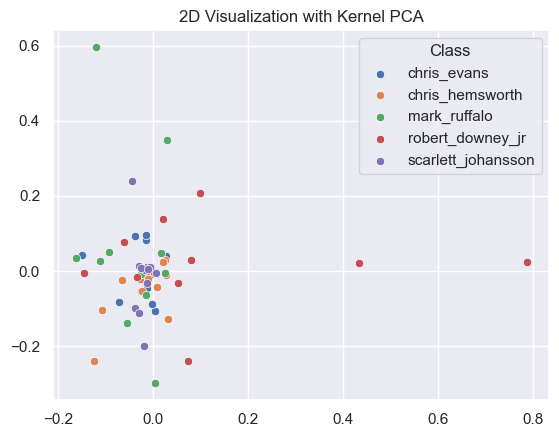

In [40]:
visualization_2d("Kernel PCA",kpca_2d_reduced)

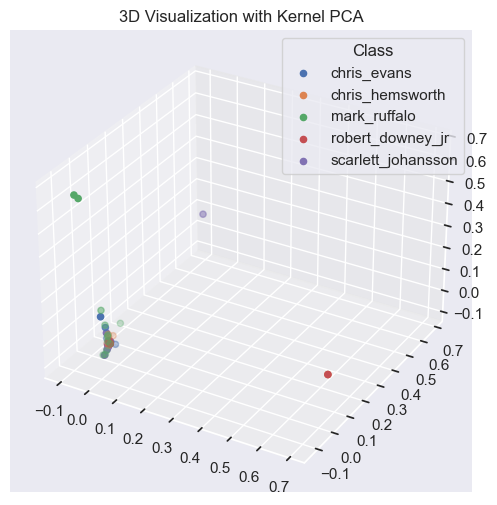

In [41]:
visualization_3d("Kernel PCA",kpca_3d_reduced)

## Random Projection

In [42]:
from sklearn.random_projection import GaussianRandomProjection

In [43]:
grp = GaussianRandomProjection(n_components=50, random_state=42)
grp.fit(flat_images)

GaussianRandomProjection(n_components=50, random_state=42)

In [44]:
grp_reduced = grp.transform(flat_images)

In [45]:
grp_recovered = grp.inverse_transform(grp_reduced)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


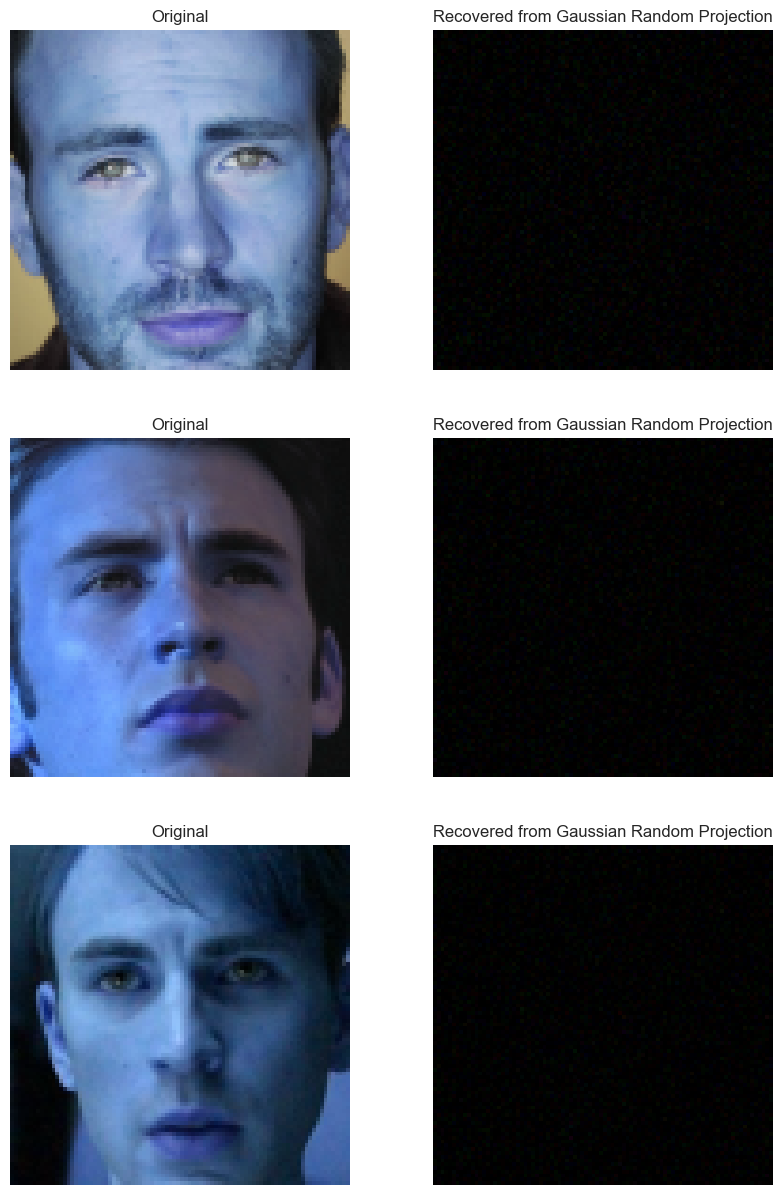

In [46]:
visualize_faces("Gaussian Random Projection",grp_recovered)

**Random Projection** is not good for **reconstruction** or **visualization** cause It doesnt learn from the data, so It cant preserve its structure like shapes or faces.

In [47]:
print("Error between original and recovered images:",mean_squared_error(flat_images,grp_recovered))

Error between original and recovered images: 0.31601523600787723


In [91]:
# Visualization
grp_2d = GaussianRandomProjection(n_components=2, random_state=42)
grp_2d_reduced = grp_2d.fit_transform(flat_images)
dump(grp_2d,"estimators/grp_2d.pkl")

grp_3d = GaussianRandomProjection(n_components=3, random_state=42)
grp_3d_reduced = grp_3d.fit_transform(flat_images)
dump(grp_3d,"estimators/grp_3d.pkl")

['estimators/grp_3d.pkl']

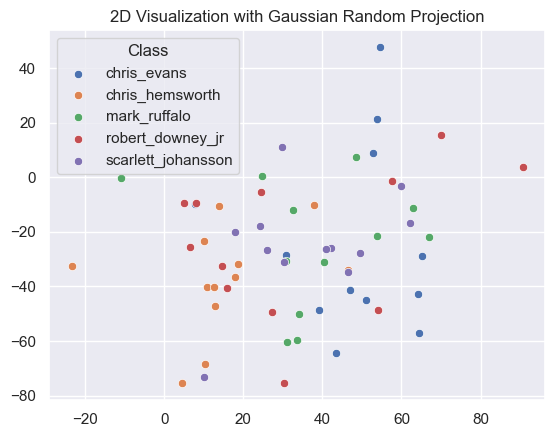

In [49]:
visualization_2d("Gaussian Random Projection",grp_2d_reduced)

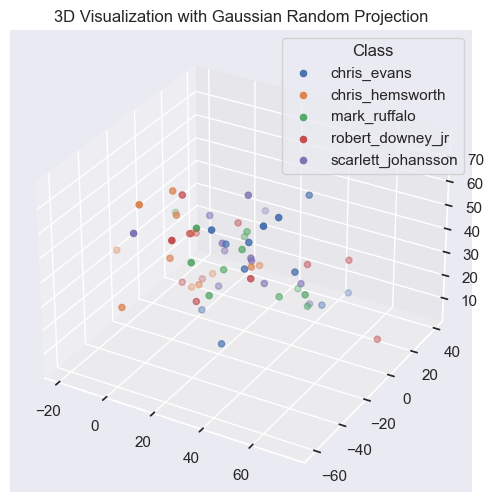

In [50]:
visualization_3d("Gaussian Random Projection",grp_3d_reduced)

## Locally Linear Embedding

In [51]:
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.metrics import pairwise_distances
from sklearn.manifold import trustworthiness

In [52]:
lle = LocallyLinearEmbedding(n_neighbors=3, n_components=50,
method='standard')
lle.fit(flat_images)

LocallyLinearEmbedding(n_components=50, n_neighbors=3)

In [53]:
lle_reduced = lle.transform(flat_images)

In [54]:
# Compare pairwise distances in high-dim and low-dim space
D_high = pairwise_distances(flat_images)
D_low = pairwise_distances(lle_reduced)

In [55]:
# Correlation or stress between distances
correlation = np.corrcoef(D_high.ravel(), D_low.ravel())[0, 1]
print(f"Distance correlation: {correlation:.4f}")

Distance correlation: 0.5899


**moderate**, not great, but LLE is not designed for global structure.

In [56]:
tw = trustworthiness(flat_images, lle_reduced, n_neighbors=10)
print(f"Trustworthiness: {tw:.4f}")

Trustworthiness: 0.7294


This shows a moderate local neighborhood preservation, though it's still below 0.9, which is usually considered strong.

These scores suggest that your current LLE configuration is **closer to acceptable**,

In [92]:
# Visualization
lle_2d = LocallyLinearEmbedding(n_neighbors=3, n_components=2,method='standard')
lle_2d_reduced = lle_2d.fit_transform(flat_images)
dump(lle_2d,"estimators/lle_2d.pkl")

lle_3d = LocallyLinearEmbedding(n_neighbors=3, n_components=3,method='standard')
lle_3d_reduced = lle_3d.fit_transform(flat_images)
dump(lle_3d,"estimators/lle_3d.pkl")

['estimators/lle_3d.pkl']

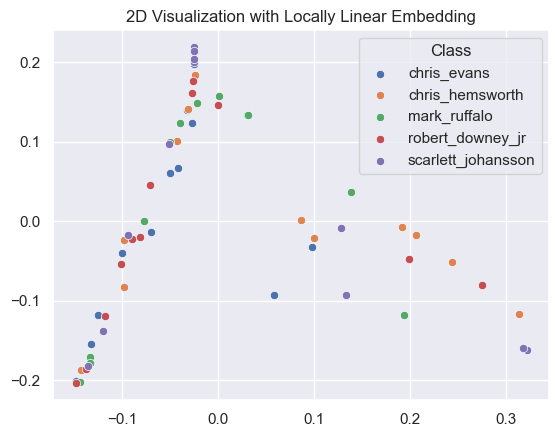

In [58]:
visualization_2d("Locally Linear Embedding",lle_2d_reduced)

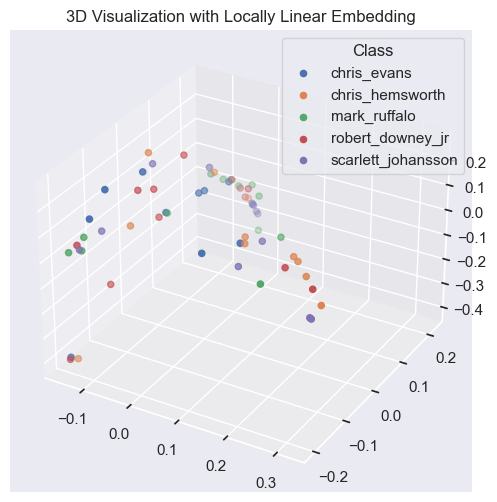

In [59]:
visualization_3d("Locally Linear Embedding",lle_3d_reduced)

## Multi Dimentional Scaling

In [60]:
from sklearn.manifold import MDS

In [61]:
mds = MDS(n_components=50)

In [62]:
mds_reduced = mds.fit_transform(flat_images)

In [63]:
# Compare pairwise distances in high-dim and low-dim space
D_high = pairwise_distances(flat_images)
D_low = pairwise_distances(mds_reduced)

In [64]:
# Correlation or stress between distances
correlation = np.corrcoef(D_high.ravel(), D_low.ravel())[0, 1]
print(f"Distance correlation: {correlation:.4f}")

Distance correlation: 0.9994


In [65]:
tw = trustworthiness(flat_images, mds_reduced, n_neighbors=10)
print(f"Trustworthiness: {tw:.4f}")

Trustworthiness: 0.9988


those are **exceptionally high scores**.

In [93]:
# Visualization
mds_2d = MDS(n_components=2)
mds_2d_reduced = mds_2d.fit_transform(flat_images)
dump(mds_2d,"estimators/mds_2d.pkl")

mds_3d = MDS(n_components=3)
mds_3d_reduced = mds_3d.fit_transform(flat_images)
dump(mds_3d,"estimators/mds_3d.pkl")

['estimators/mds_3d.pkl']

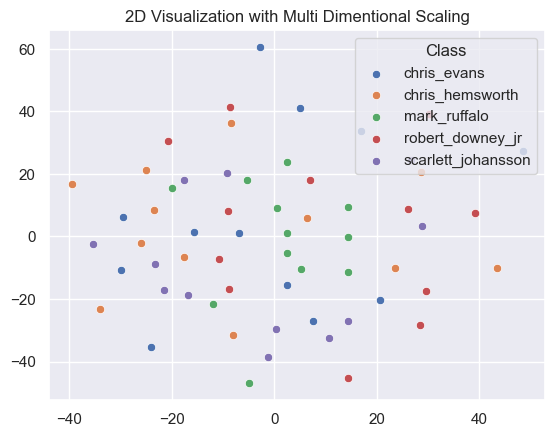

In [67]:
visualization_2d("Multi Dimentional Scaling",mds_2d_reduced)

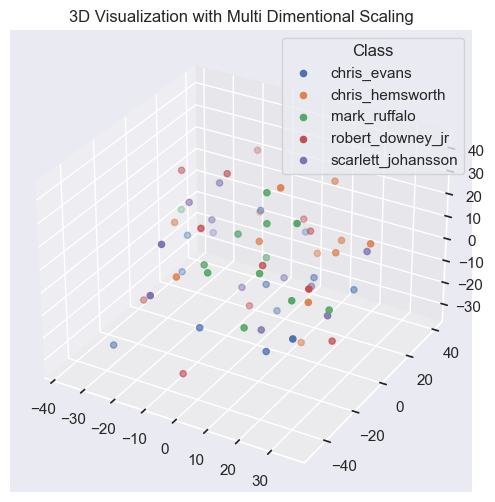

In [68]:
visualization_3d("Multi Dimentional Scaling",mds_3d_reduced)

## Isomap

In [69]:
from sklearn.manifold import Isomap

In [70]:
isomap = Isomap(n_components=33,n_neighbors=10)
isomap.fit(flat_images)

Isomap(n_components=33, n_neighbors=10)

In [71]:
isomap_reduced = isomap.transform(flat_images)

In [72]:
# Compare pairwise distances in high-dim and low-dim space
D_high = pairwise_distances(flat_images)
D_low = pairwise_distances(isomap_reduced)

In [73]:
# Correlation or stress between distances
correlation = np.corrcoef(D_high.ravel(), D_low.ravel())[0, 1]
print(f"Distance correlation: {correlation:.4f}")

Distance correlation: 0.9241


This means **92% of the pairwise** distance relationships are preserved.
Isomap is known to capture global structure, so this score is strong.

In [74]:
tw = trustworthiness(flat_images, isomap_reduced, n_neighbors=10)
print(f"Trustworthiness: {tw:.4f}")

Trustworthiness: 0.9790


Outstanding. A score > 0.95 means that local neighborhoods are nearly perfectly preserved.
This is better than LLE and even close to what you got from MDS — with the added benefit that Isomap supports .transform().

In [94]:
# Visualization
isomap_2d = Isomap(n_components=2,n_neighbors=10)
isomap_2d_reduced = isomap_2d.fit_transform(flat_images)
dump(isomap_2d,"estimators/isomap_2d.pkl")

isomap_3d = Isomap(n_components=3,n_neighbors=10)
isomap_3d_reduced = isomap_3d.fit_transform(flat_images)
dump(isomap_3d,"estimators/isomap_3d.pkl")

['estimators/isomap_3d.pkl']

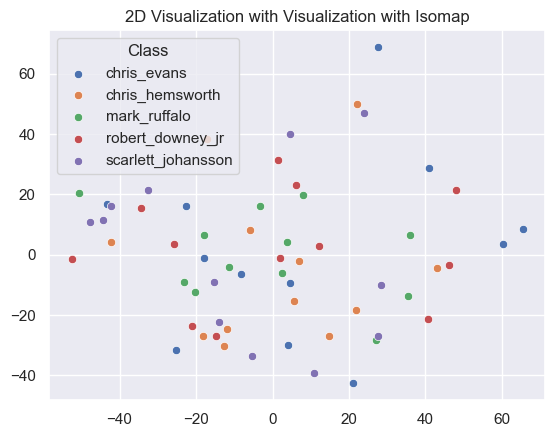

In [76]:
visualization_2d("Visualization with Isomap",isomap_2d_reduced)

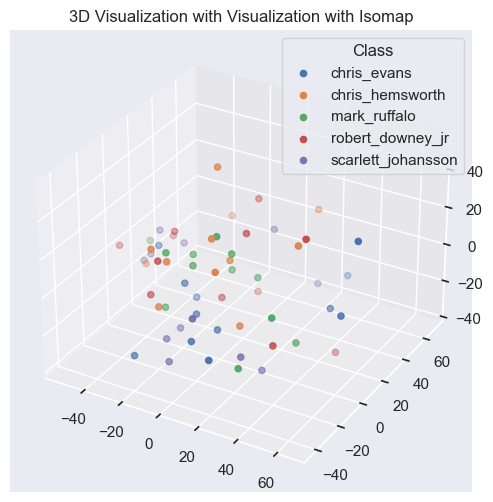

In [77]:
visualization_3d("Visualization with Isomap",isomap_3d_reduced)

## TSNE

In [78]:
from sklearn.manifold import TSNE

In [79]:
tsne = TSNE(n_components=33, method='exact', random_state=42)

In [80]:
tsne_reduced = tsne.fit_transform(flat_images)

In [81]:
# Compare pairwise distances in high-dim and low-dim space
D_high = pairwise_distances(flat_images)
D_low = pairwise_distances(tsne_reduced)

In [82]:
# Correlation or stress between distances
correlation = np.corrcoef(D_high.ravel(), D_low.ravel())[0, 1]
print(f"Distance correlation: {correlation:.4f}")

Distance correlation: -0.0727


That's **very bad**. It means global distances were not preserved at all.
Negative correlation suggests the structure in high-dimensional space was almost inverted or unrelated.

In [83]:
tw = trustworthiness(flat_images, tsne_reduced, n_neighbors=10)
print(f"Trustworthiness: {tw:.4f}")

Trustworthiness: 0.6264


This is average at best.
For t-SNE, trustworthiness should typically be > 0.90 when it works well.

In [105]:
# Visualization
tsne_2d = TSNE(n_components=2, method='exact', random_state=42)
tsne_2d_reduced = tsne_2d.fit_transform(flat_images)

tsne_3d = TSNE(n_components=3, method='exact', random_state=42)
tsne_3d_reduced = tsne_3d.fit_transform(flat_images)

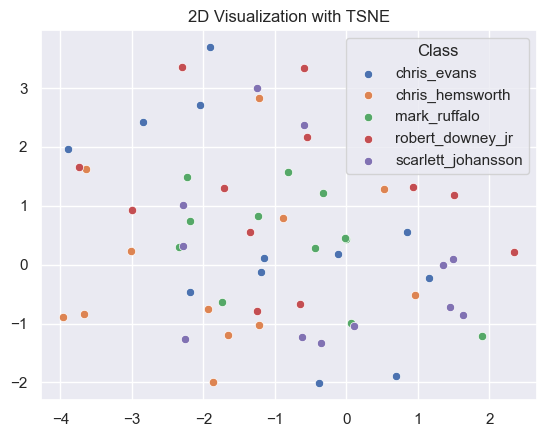

In [85]:
visualization_2d("TSNE",tsne_2d_reduced)

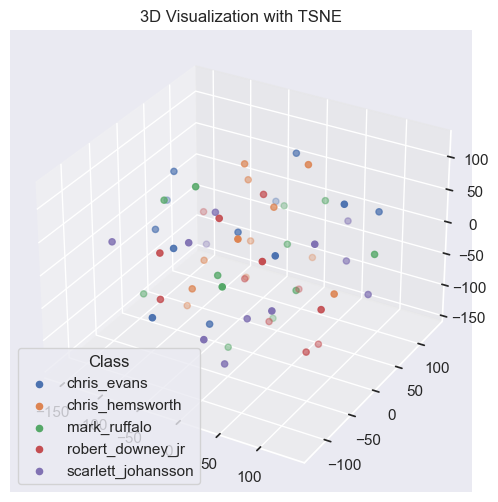

In [86]:
visualization_3d("TSNE",tsne_3d_reduced)